# Tutorial

This tutorial demonstrates how to use LineageVI for RNA velocity analysis with gene programs.


In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
# Library loading
import lineagevi
import scanpy as sc
import scvelo as scv
import numpy as np
import os

In [81]:
# Download pancreas dataset
adata = scv.datasets.pancreas()

In [82]:
# Obtain raw counts for the annotation step
adata.X = adata.layers['unspliced'].copy() + adata.layers['spliced'].copy()
adata.layers['counts'] = adata.X.copy()

In [83]:
# Explore available libraries
libs = lineagevi.utils.list_enrichr_libraries()
print(libs[["libraryName", "numTerms"]].head())

                        libraryName  numTerms
0               Genome_Browser_PWMs       615
1          TRANSFAC_and_JASPAR_PWMs       326
2         Transcription_Factor_PPIs       290
3                         ChEA_2013       353
4  Drug_Perturbations_from_GEO_2014       701


In [84]:
# Download several into a directory
lineagevi.utils.download_enrichr_libraries(
    ["GO_Biological_Process_2025", "GO_Molecular_Function_2025"],
    output_dir="/home/lgolinelli/git/lineageVI/gene_sets",
)

['/home/lgolinelli/git/lineageVI/gene_sets/GO_Biological_Process_2025.gmt',
 '/home/lgolinelli/git/lineageVI/gene_sets/GO_Molecular_Function_2025.gmt']

In [85]:
# Create the binary matrix of gene sets, filtering out any gene program with less than 12 genes for interpretability.
bio_process_path = '/home/lgolinelli/git/lineageVI/gene_sets/GO_Biological_Process_2025.gmt'
min_genes=20
lineagevi.utils.add_annotations(
    adata, 
    files=[bio_process_path],
    min_genes=min_genes,
    varm_key='I',
    uns_key='terms',
    clean=False,
    genes_use_upper=True)

# Remove genes not present in any retained terms.
adata._inplace_subset_var(adata.varm['I'].sum(1) > 0)

In [86]:
# Standard scVelo preprocessing
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000, subset_highly_variable=True, log=True)
scv.pp.moments(adata, n_pcs=100, n_neighbors=200) # Smoothing over 200 neighbors helps to denoise the biological trajectories for RNA velocity analysis.
sc.tl.leiden(adata) # Using clusters helps the model to learn multi-lineage dynamics.

Filtered out 6561 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 3000 highly variable genes.
Logarithmized X.


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2831916/2212733455.py:3: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=100, n_neighbors=200) # Smoothing over 200 neighbors helps to denoise the biological trajectories for RNA velocity analysis.
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [87]:
# We remove terms that contain less than 12 genes after filtering out HVGs.
select_terms = adata.varm['I'].sum(0)>min_genes
adata.uns['terms'] = np.array(adata.uns['terms'])[select_terms].tolist()
adata.varm['I'] = adata.varm['I'][:, select_terms]

# Again, we remove genes not present in any retained terms.
adata._inplace_subset_var(adata.varm['I'].sum(1)>0) 

In [88]:
# We store the matrix of neighbors indices in the AnnData object; required for training. 
lineagevi.utils.get_neighbor_indices(adata, K=20, neighbors_key='neighbors', indices_key='indices')  # Gets 20 neighbors + self = 21 total

In [89]:
adata.varm['I'].shape

(2765, 420)

In [140]:
# Model initialization
vae = lineagevi.LineageVI(
    adata=adata,
    n_hidden=128,
    n_layers = 2,
    dropout = 0,
    mask_key='I',
    unspliced_key='Mu', # make sure to use smoothed spliced and unspliced expression values: 'Mu' and 'Ms'
    spliced_key='Ms',
    nn_key='indices',
    cluster_key=None,  # Key in adata.obs
    cluster_embedding_dim=12,  # Optional, default is 32
)

history = vae.fit(
    K=10,
    batch_size=256,
    lr_regime1=1e-2,
    lr_regime2=1e-2,
    train_size=0.9,
    velocity_loss_weight_gene = 1.0,
    velocity_loss_weight_gp = 0,
    epochs1=400, #initially 400
    epochs2=150, #initially 100
    seeds=(0, 1, 2),
    output_dir='/home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas',   # or None
    verbose=1,
    monitor_genes=['Gnas', 'Rbfox3'],
    monitor_negative_velo=True,
    monitor_every_epochs=25,
    #kl_weight = 0.1,
    kl_weight_schedule='linear',
    kl_weight_min=0.0,
    kl_weight_max=.5,
    kl_cycle_ramp_frac=0.2,
)

Train/val split: 3326 train, 370 val (train_size=0.9)
[Regime1] Epoch 1/400 - train loss: 11.1426 (recon: 11.1426, kl: 3044.7769) - val loss: 7.4004 (recon: 7.4004, kl: 9237.8465)
[Regime1] Epoch 2/400 - train loss: 26.9138 (recon: 8.0646, kl: 2978.1646) - val loss: 11.0733 (recon: 9.5296, kl: 243.9087)
[Regime1] Epoch 3/400 - train loss: 11.1121 (recon: 9.0668, kl: 161.5817) - val loss: 9.7678 (recon: 8.2317, kl: 121.3549)
[Regime1] Epoch 4/400 - train loss: 10.0032 (recon: 8.3646, kl: 86.2955) - val loss: 9.4525 (recon: 8.0050, kl: 76.2305)
[Regime1] Epoch 5/400 - train loss: 9.5531 (recon: 7.9422, kl: 63.6298) - val loss: 9.0594 (recon: 7.4919, kl: 61.9135)
[Regime1] Epoch 6/400 - train loss: 9.1530 (recon: 7.4341, kl: 54.3182) - val loss: 8.8015 (recon: 7.0760, kl: 54.5235)
[Regime1] Epoch 7/400 - train loss: 8.9201 (recon: 7.1952, kl: 45.4205) - val loss: 8.6138 (recon: 6.7737, kl: 48.4568)
[Regime1] Epoch 8/400 - train loss: 8.7011 (recon: 6.9183, kl: 40.2402) - val loss: 8.4229 

KeyboardInterrupt: 

In [ ]:
vae.get_model_outputs(
    adata=adata,
    return_negative_velo=False,
    base_seed=0,
    save_to_adata=True,
    unspliced_key='Mu',
    spliced_key='Ms',
    nn_key='indices',
    rescale_velocity_magnitude=False, # the more turbulent the velocity flow, the smaller the velocity magnitude
    max_velocity_magnitude=1,
)

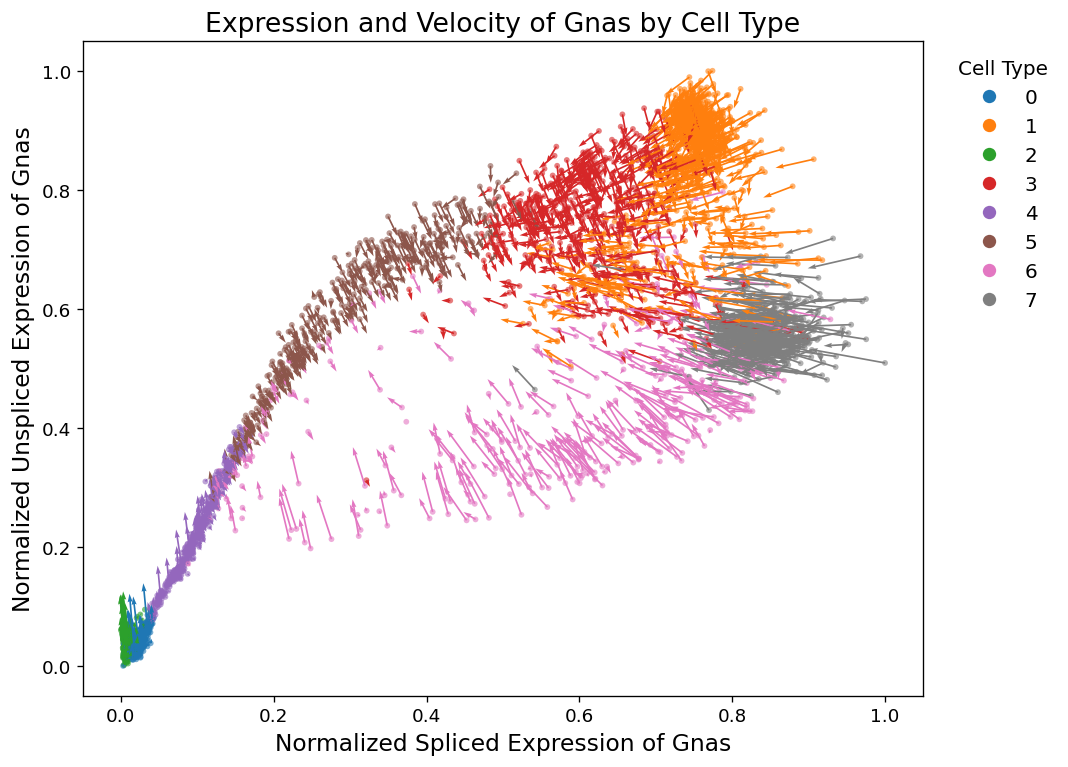

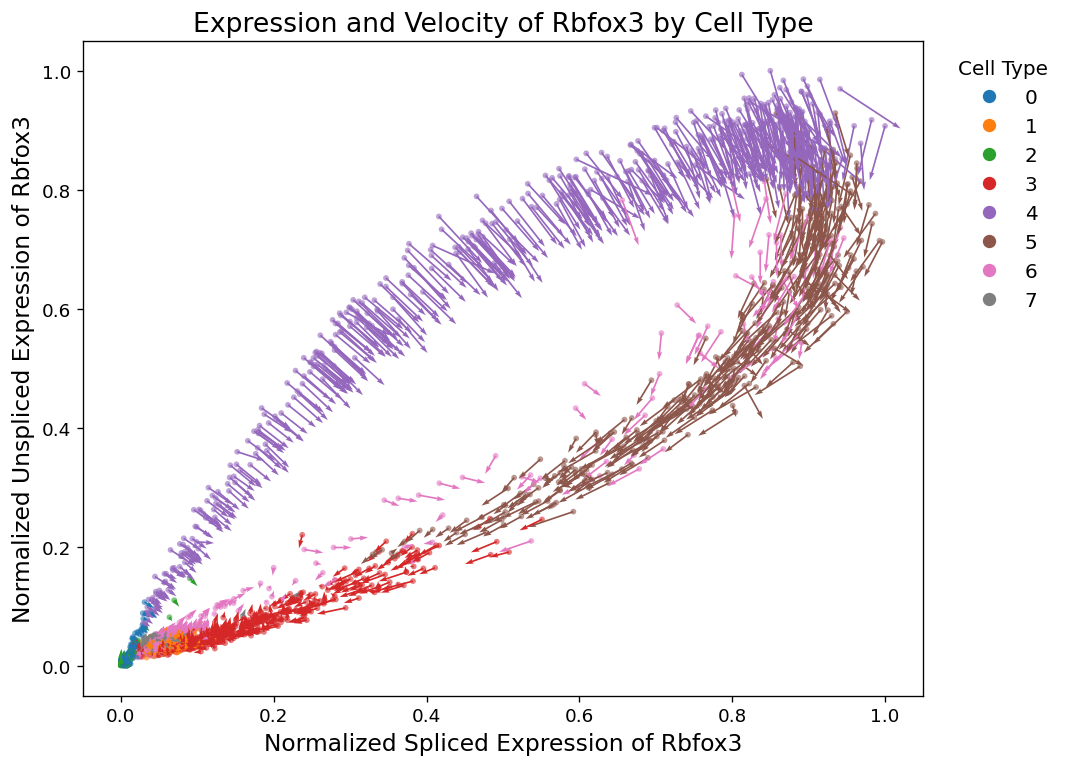

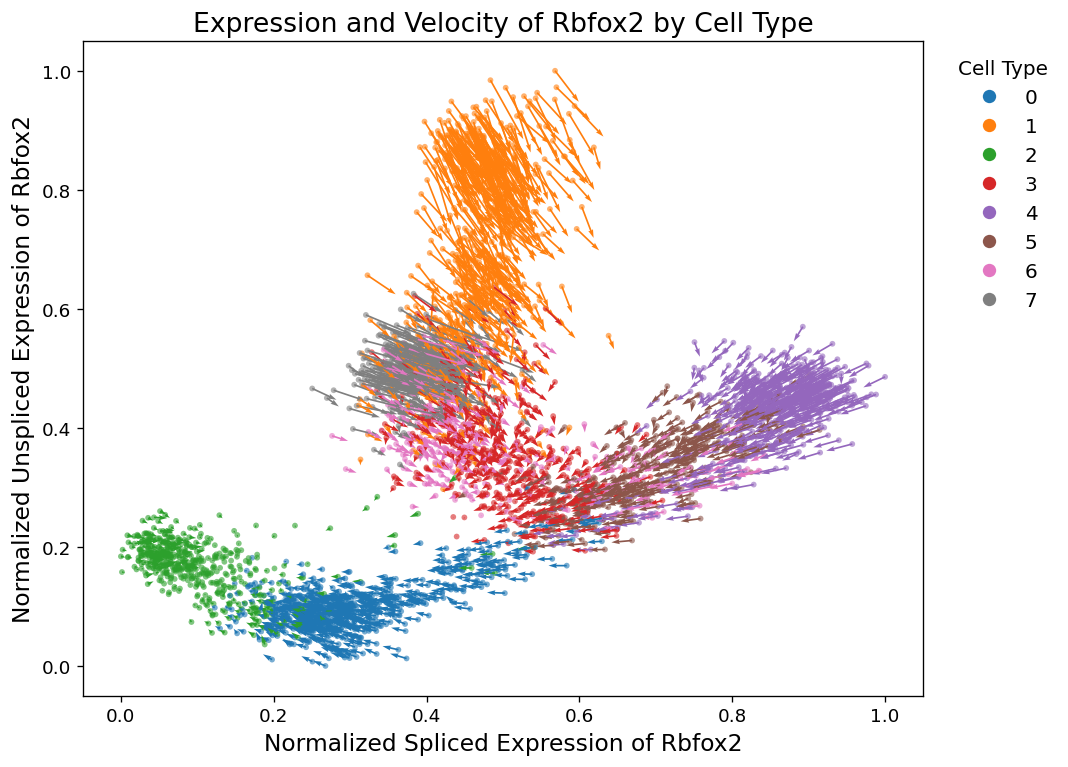

(<Figure size 1080x780 with 1 Axes>,
 <Axes: title={'center': 'Expression and Velocity of Rbfox2 by Cell Type'}, xlabel='Normalized Spliced Expression of Rbfox2', ylabel='Normalized Unspliced Expression of Rbfox2'>)

In [ ]:
lineagevi.plots.plot_phase_plane(adata,  'Gnas', cluster_key='leiden', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox3', cluster_key='leiden', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox2', cluster_key='leiden', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)

computing velocity graph (using 1/64 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/l

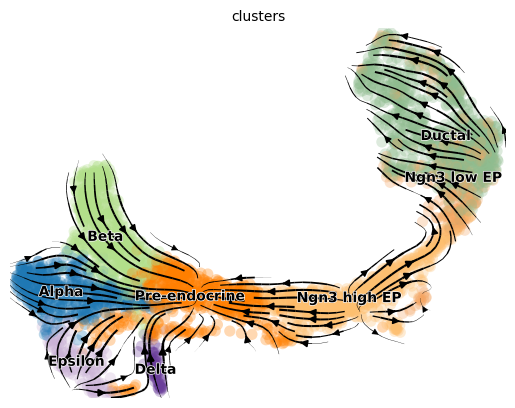

/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/l

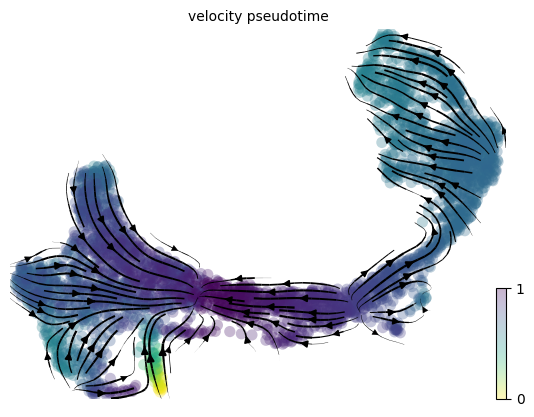

In [ ]:
cluster_key='clusters'

sc.pp.neighbors(adata)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata)
scv.pl.velocity_embedding_stream(adata, color=cluster_key)
scv.tl.velocity_pseudotime(adata)
scv.pl.velocity_embedding_stream(adata, color='velocity_pseudotime')

In [ ]:
lineagevi.plots.top_features_table(adata, groupby_key="clusters", categories=['Beta'], layer="velocity", n=10)

,feature,mean_activation,Beta mean
1,Iapp,-255.998672,-255.998672
2,Nnat,-59.699600,-59.699600
3,Rbp4,-18.544544,-18.544544
4,Npy,-9.459812,-9.459812
5,Ttr,-9.353161,-9.353161
6,Gcg,-9.157337,-9.157337
7,Dlk1,-8.719534,-8.719534
8,Sst,-7.701244,-7.701244
9,Sec61b,-7.490223,-7.490223
10,Calr,-7.411028,-7.411028


computing velocity graph (using 1/64 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


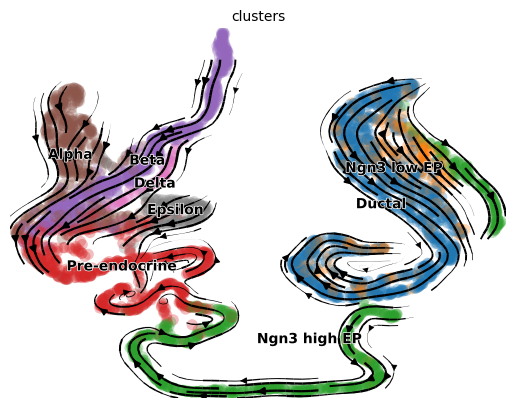

/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


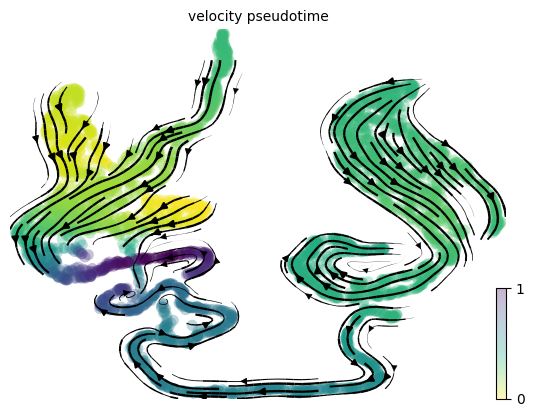

In [ ]:
adata_gp = lineagevi.utils.build_gp_adata(adata)
sc.pp.neighbors(adata_gp)
sc.tl.umap(adata_gp)
scv.tl.velocity_graph(adata_gp)
scv.pl.velocity_embedding_stream(adata_gp, color=cluster_key)
scv.tl.velocity_pseudotime(adata_gp)
scv.pl.velocity_embedding_stream(adata_gp, color='velocity_pseudotime')

In [ ]:
lineagevi.plots.top_features_table(adata_gp, groupby_key="clusters", categories=['Beta'], layer="z", n=10)

,feature,mean_activation,Beta mean
1,Negative Regulation of Cell Population Prolife...,1.377927,1.377927
2,Adenylate Cyclase-Modulating G Protein-Coupled...,-0.950878,-0.950878
3,Gene Expression (GO:0010467),-0.783081,-0.783081
4,Adenylate Cyclase-Activating G Protein-Coupled...,-0.606116,-0.606116
5,Regulation of Protein Secretion (GO:0050708),0.366041,0.366041
6,Regulation of Insulin Secretion (GO:0050796),-0.186700,-0.186700
7,Protein Metabolic Process (GO:0019538),0.166452,0.166452
8,Positive Regulation of Macromolecule Biosynthe...,-0.131669,-0.131669
9,Regulation of Gene Expression (GO:0010468),-0.113820,-0.113820
10,Positive Regulation of Gene Expression (GO:001...,0.109517,0.109517


In [ ]:
#sc.pl.violin(adata_gp, keys='FETAL_PANCREAS_ISLET_ENDOCRINE', layer='z', groupby='clusters')

In [ ]:
'''lineagevi.plots.plot_gp_phase_planes(
    adata_gp,
    program_pairs=[('FETAL_PANCREAS_ISLET_ENDOCRINE', '88')],
    cluster_key='clusters',
    title='Phase Planes',
    figsize_per_panel = (7, 7),
    alpha = 1,
    arrow_multiplier=.01
)'''

"lineagevi.plots.plot_gp_phase_planes(\n    adata_gp,\n    program_pairs=[('FETAL_PANCREAS_ISLET_ENDOCRINE', '88')],\n    cluster_key='clusters',\n    title='Phase Planes',\n    figsize_per_panel = (7, 7),\n    alpha = 1,\n    arrow_multiplier=.01\n)"

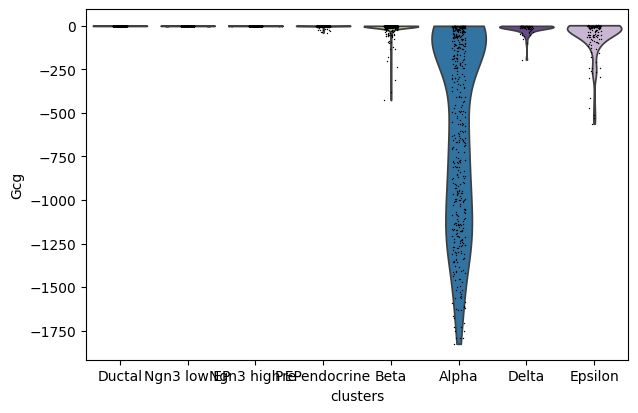

In [ ]:
sc.pl.violin(adata, keys='Gcg', layer='velocity', groupby='clusters')

In [ ]:
#sc.pl.scatter(adata_gp, x='velocity_pseudotime', y='88', color='clusters', layers='velocity', size=10, alpha=0.5, title='Clusters')

In [ ]:
#sc.pl.scatter(adata_gp, x='velocity_pseudotime', y='88', color='clusters', layers='z', size=10, alpha=0.5, title='Clusters')

In [ ]:
#sc.pl.scatter(adata, x='velocity_pseudotime', y='Gnas', color='clusters', layers='velocity', size=10, alpha=0.5, title='Clusters')

In [ ]:
#sc.pl.scatter(adata, x='velocity_pseudotime', y='Gnas', color='clusters', layers='Ms', size=10, alpha=0.5, title='Clusters')

In [ ]:
# Differential expression (e.g. spliced layer)
#de = vae.differential(adata, "clusters", mode="expression", layer="Ms")
# de["Beta"] has columns: difference, pval, padj; index = gene names

# Differential latent (gene program activations)
dlatent = vae.differential(adata, "clusters", mode="latent")
adata.uns['differential_latent'] = dlatent

# Differential gene velocity
#dvelo = vae.differential(adata, "clusters", mode="gene_velocity")

# Differential GP velocity
#dgp = vae.differential(adata, "clusters", mode="gp_velocity")

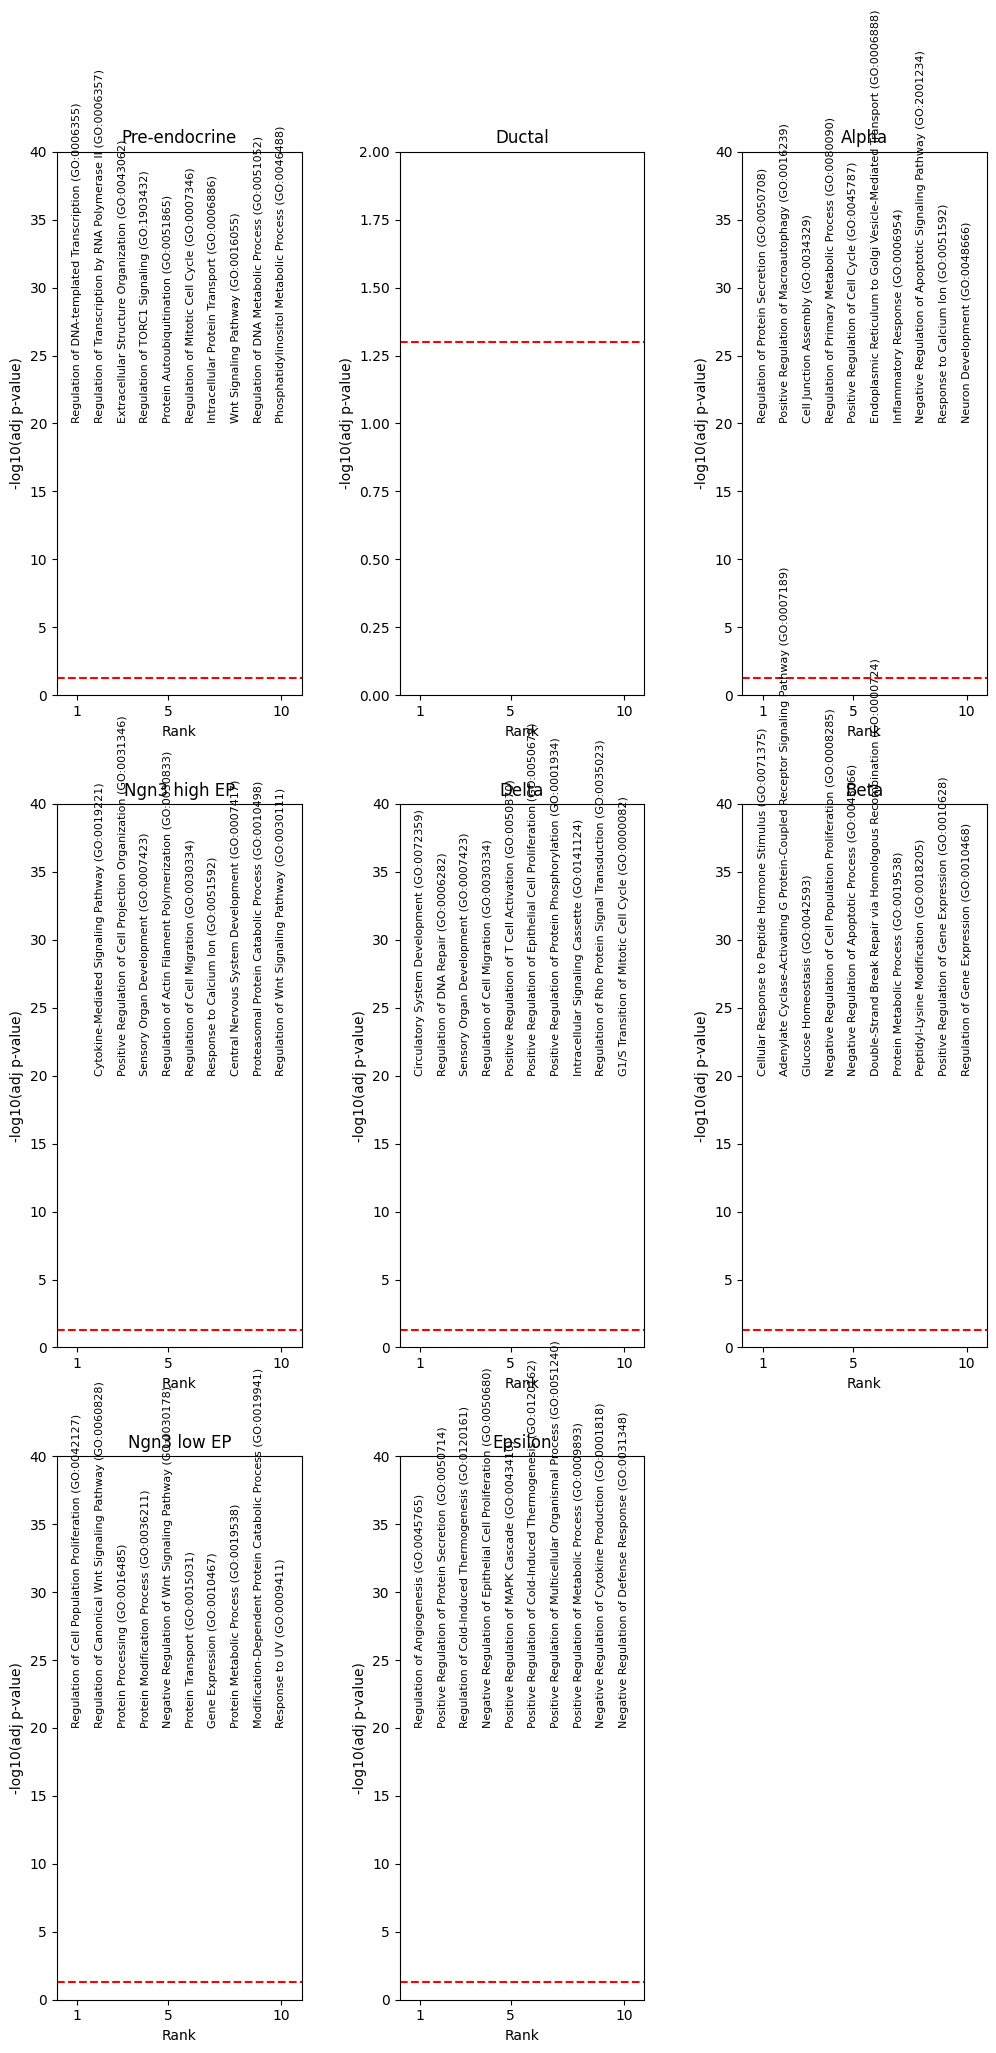

In [ ]:
lineagevi.plots.plot_differential(adata, scores_key='differential_latent', n_points=10, lim_val=1.3)